In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency


warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [9]:
df = pd.read_csv('../trabajo_final/data/income_data.csv')

# Data Preview

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [13]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


La variable objetivo es income

In [11]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [16]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(num_cols)
print(cat_cols)

['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


# Hipotesis

1. Educación: A mayor nivel educativo, es mayor el ingreso de superar los 50K
2. Edad: Los ingresos tienden a subir con la edad, en relacion con la experiencia
3. Horas semanales: Los que trabajan mas de 40h estan mas en la parte de ingresos mayores a 50K
4. Sexo: El sexo influye en el ingreso
5. Estado civil: Las personas casadas tienen mas ingresos por su estabilidad

### Educación

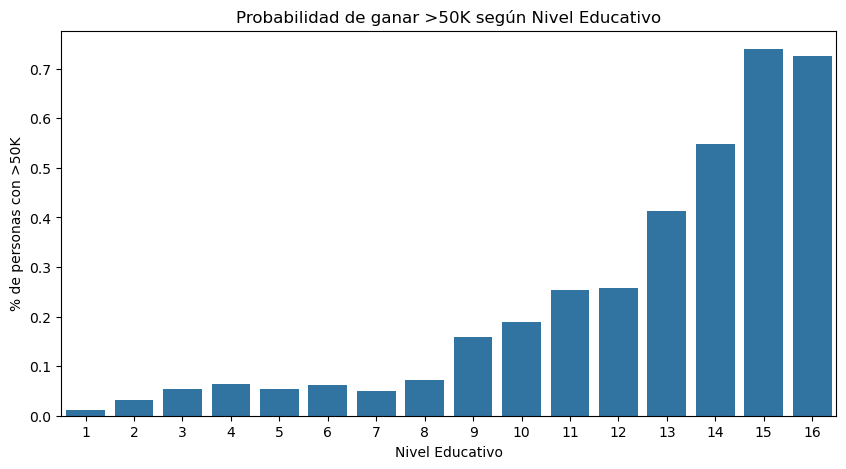

In [26]:
# Convertimos el income a numérico
df['income_bin'] = (df['income'] == '>50K').astype(int)

# Agrupamos por nivel educativo y calculamos la media
edu_prob = df.groupby('educational-num')['income_bin'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=edu_prob, x='educational-num', y='income_bin')
plt.title('Probabilidad de ganar >50K según Nivel Educativo')
plt.ylabel('% de personas con >50K')
plt.xlabel('Nivel Educativo')
plt.show()

Podemos ver que la hipotesis se cumple, porque vemos un crecimiento en proporcional del nivel educativo con los que ganan mas de 50K

### Edad

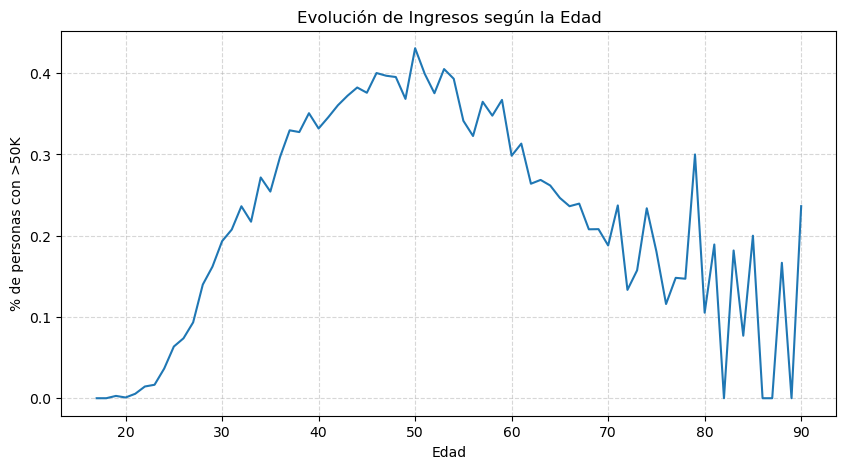

In [27]:
# Agrupamos por edad para ver la tendencia
age_trend = df.groupby('age')['income_bin'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_trend, x='age', y='income_bin')
plt.title('Evolución de Ingresos según la Edad')
plt.ylabel('% de personas con >50K')
plt.xlabel('Edad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Esta hipotesis se acepta durante un periodo de tiempo, luego vemos que la grafica baja, porque la gente se va jubilando, entonces tiene menos ingresos

### Horas semanales

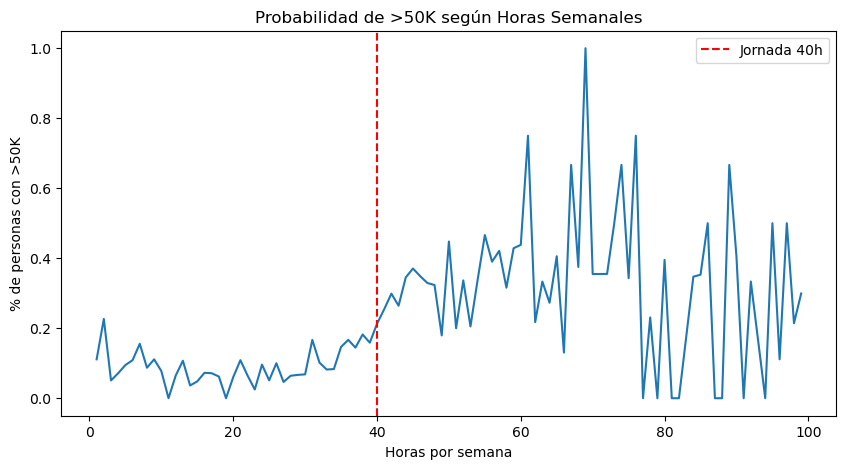

In [ ]:
# Hecho por IA
# Agrupamos por horas para calcular el % de personas con >50K
hours_trend = df.groupby('hours-per-week')['income_bin'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hours_trend, x='hours-per-week', y='income_bin')

# Añadimos una línea vertical en las 40h para marcar la referencia
plt.axvline(40, color='red', linestyle='--', label='Jornada 40h')

plt.title('Probabilidad de >50K según Horas Semanales')
plt.ylabel('% de personas con >50K')
plt.xlabel('Horas por semana')
plt.legend()
plt.show()

Confirmamos la hipotesis, existe una relacion directa entre las horas trabajadas y los ingresos

### Sexo

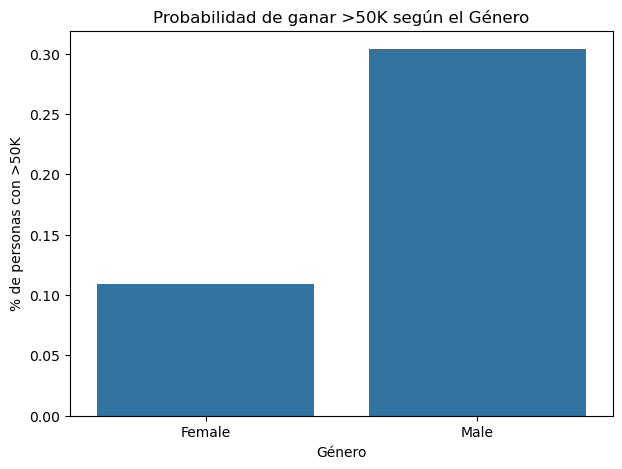

In [ ]:
# Calculamos la probabilidad de ingresos altos por género
gender_trend = df.groupby('gender')['income_bin'].mean().reset_index()

# 2. Graficamos
plt.figure(figsize=(7, 5))
sns.barplot(data=gender_trend, x='gender', y='income_bin')

plt.title('Probabilidad de ganar >50K según el Género')
plt.ylabel('% de personas con >50K')
plt.xlabel('Género')
plt.show()

La hipotesis se confirma, podemos ver que existe una brecha entre el sexo de los trabajadores, para ganar mas ingresos

### Estado civil

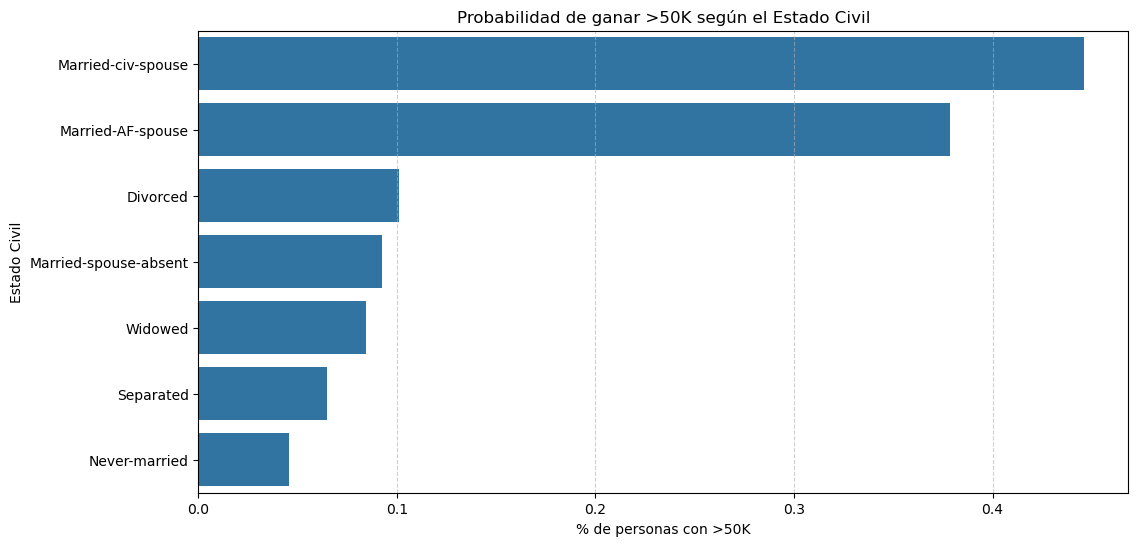

In [32]:
# Calculamos la probabilidad de ingresos altos por estado civil
marital_trend = df.groupby('marital-status')['income_bin'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=marital_trend, x='income_bin', y='marital-status')

plt.title('Probabilidad de ganar >50K según el Estado Civil')
plt.xlabel('% de personas con >50K')
plt.ylabel('Estado Civil')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

La hipotesis se vuelve a confirmar, las personas casadas son las que tienen mas ingresos. Tambien es cierto que esto tiene que ver con la edad, y como hemos visto en la hipotesis de la edad, la gente que tiene mas probabilidades de tener mas ingresos son los de 50 años. Y a esta edad estas casado normalmente

### Conclusiones:
1. 

# Análisis Univariado

Columnas númericas

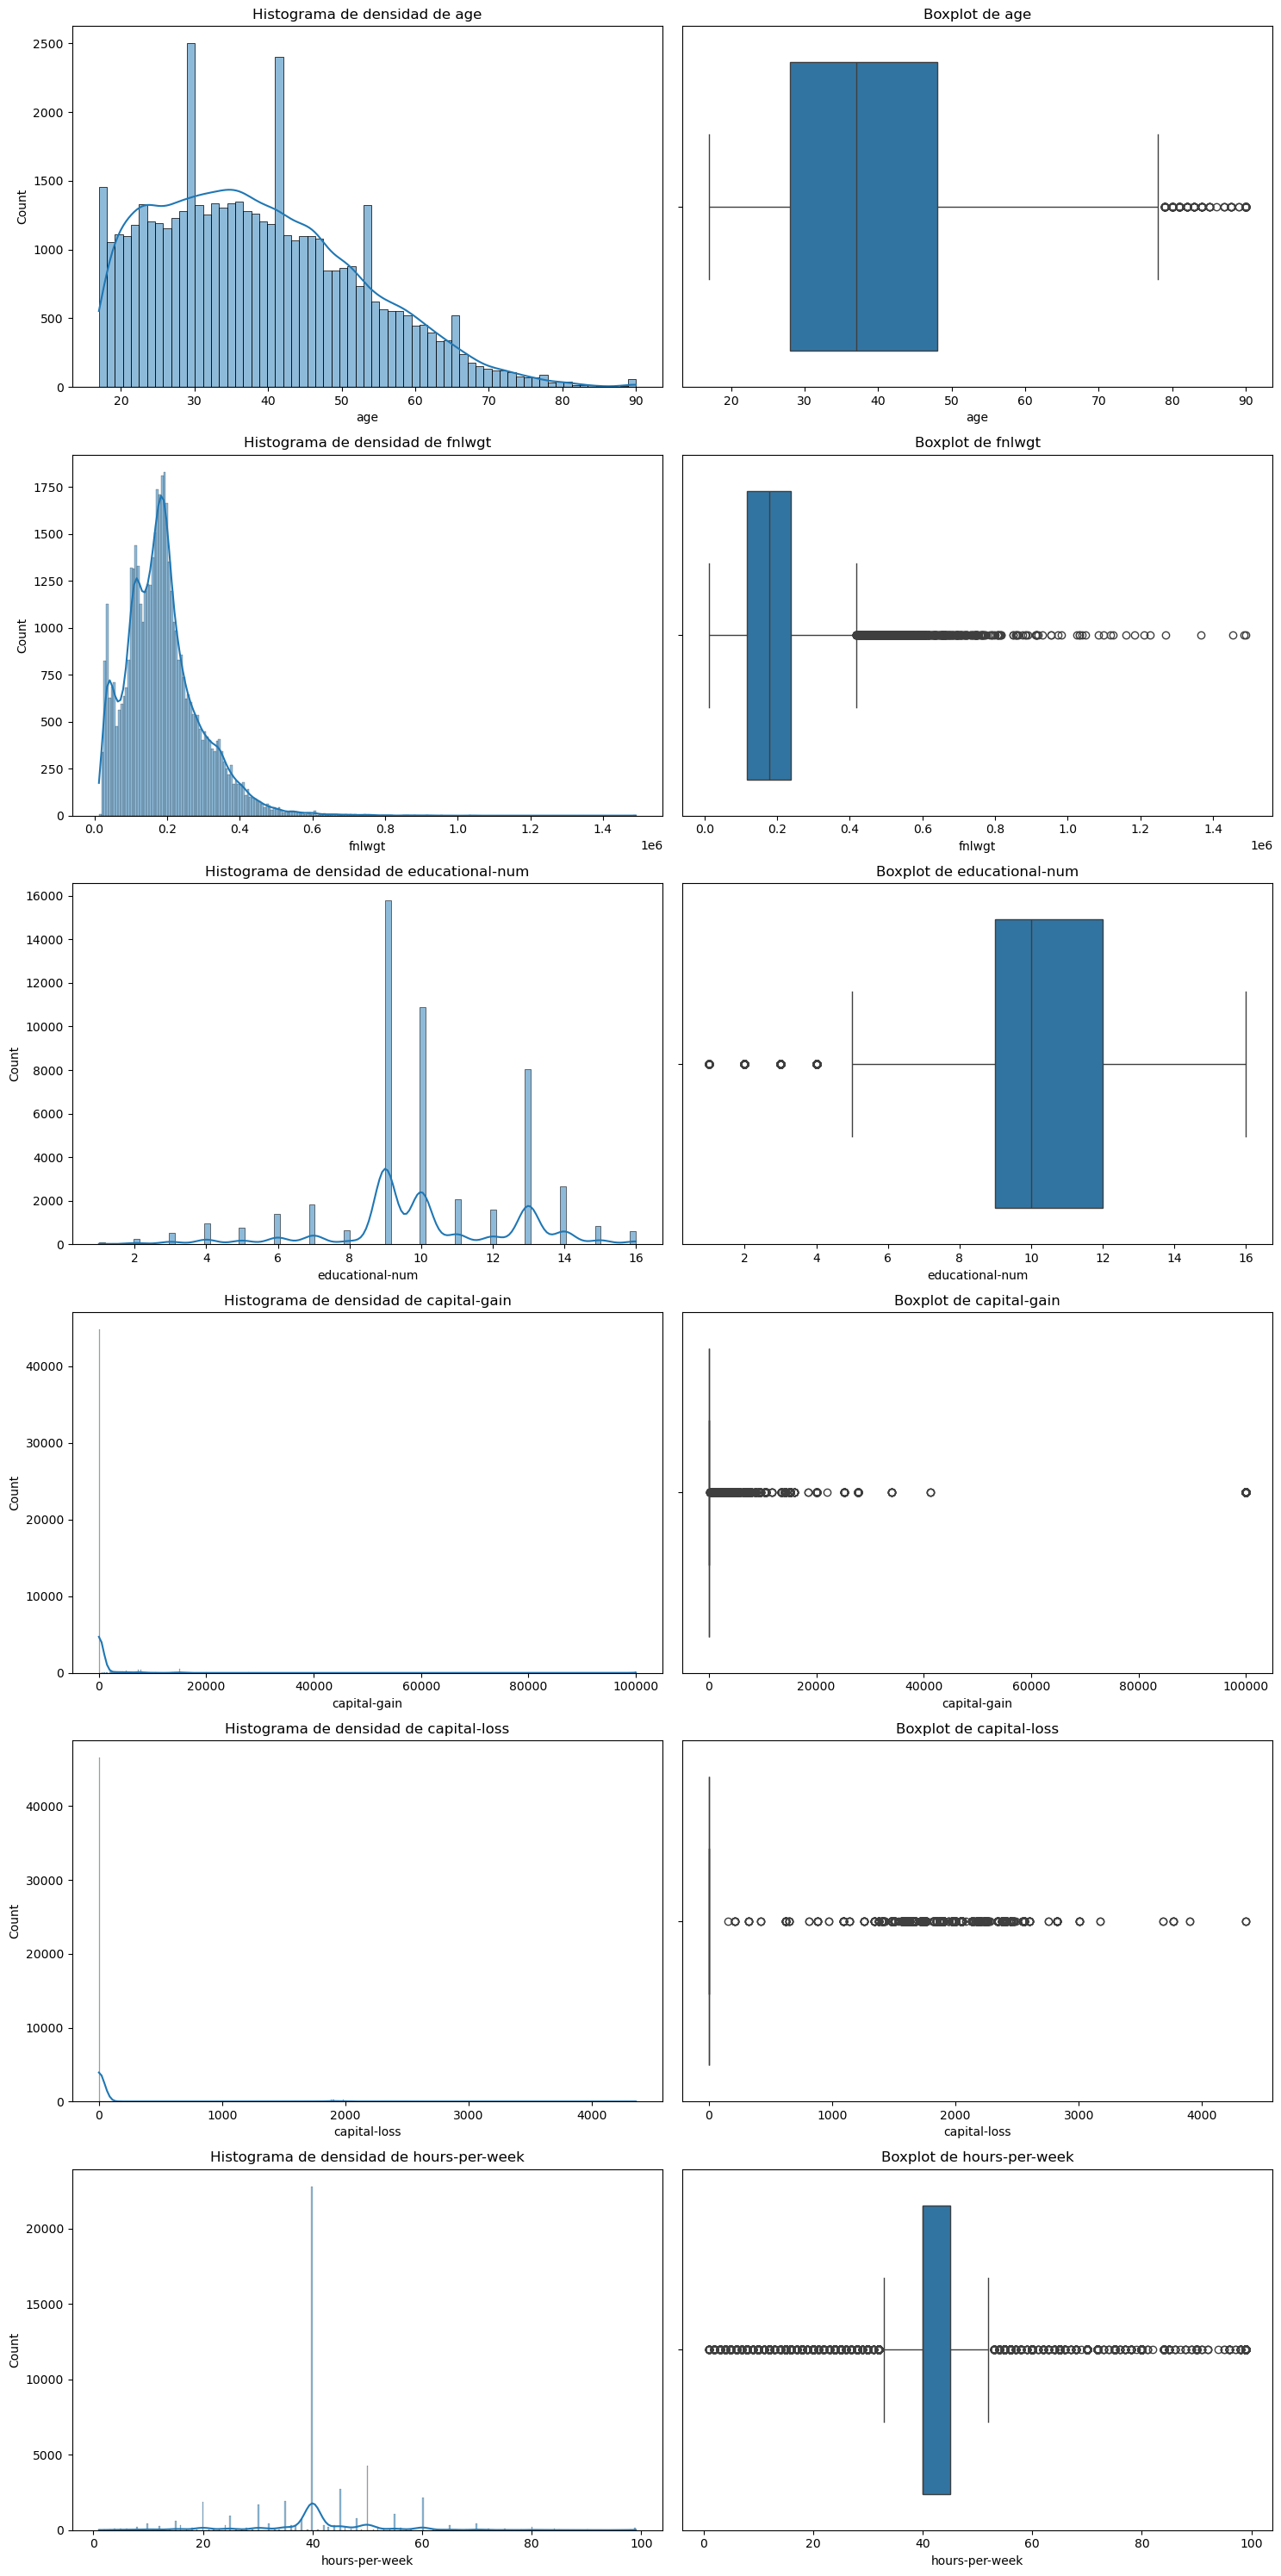

In [17]:
fig, axes = plt.subplots(nrows=len(df.select_dtypes(include=[np.number]).columns), ncols=2, figsize=(15, 5 * len(df.select_dtypes(include=[np.number]).columns)))

for i, column in enumerate(df[num_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

In [38]:
num_cols_cardinality = [col for col in num_cols if df[col].nunique()<50]
df[num_cols_cardinality].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False).style.background_gradient(cmap='coolwarm')

AttributeError: The '.style' accessor requires jinja2